This notebook is to play around with gui code for visualizing data online

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any




In [3]:
# Load config
import sys
import os
from pathlib import Path

# 

# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))

home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config


Configuration loaded successfully:
data_subfolders:
  day: 20250717
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/first_closed_loop_experiment
  table_parameters:
    PreprocessParams: {}
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
        framerate: 5
    DNoiseTraceParams:
      dnoise_params_id: 1
      fupsample_trace: 20
      fupsample_stim: 4
      ref_time: stim
      fit_kind: gradient
      skip_duplicates: true
      pre_blur_sigma_s: 0.0
      post_blur_sigma_s: 0.0
paths:
  repo_directory: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/
  home_directory: /gpfs01/euler/User/ssuhai
  dj_conf

In [4]:
# 
from simulations.loop_components.dj_wrappers import OpenRetinaWrapper

# connect populated closed loop schema

In [5]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

openretinawrapper = OpenRetinaWrapper(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )

In [6]:

# Load config and tables
openretinawrapper.load_config()
openretinawrapper.load_tables()
print("OpenRetinaWrapper loaded and configured successfully")

[2025-07-23 11:17:42,262][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-07-23 11:17:42,314][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop
OpenRetinaWrapper loaded and configured successfully


# GUI Components for Visualization

Let's create a basic GUI to visualize the data processed by the OpenRetinaWrapper.

In [7]:
from simulations.gui.data_visualization import VisualizationGUI

In [8]:
(openretinawrapper('CelltypeAssignment')() & dict(roi_id=1))

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),avg_stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,os_ds_stim_name Unique string identifier,training_data_hash hash of the classifier training data files,classifier_params_hash hash of the classifier params config,"celltype predicted group, without quality or confidence threshold",max_confidence confidence score for assigned celltype for easy restriction,confidence confidence score (probability) for all celltypes
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,gChirp,control,1,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,27,0.245469,=BLOB=


In [9]:
openretinawrapper.tables

{'UserInfo': djimaging.schemas.core_schema.UserInfo,
 'Experiment': djimaging.schemas.core_schema.Experiment,
 'Field': djimaging.schemas.core_schema.Field,
 'OpticDisk': djimaging.schemas.full_rgc_schema.OpticDisk,
 'RelativeFieldLocation': djimaging.schemas.full_rgc_schema.RelativeFieldLocation,
 'RelativeRoiLocation': djimaging.user.ssuhai.schemas.ssuhai_schema_closed_loop.RelativeRoiLocation,
 'Stimulus': djimaging.schemas.core_schema.Stimulus,
 'RoiMask': djimaging.schemas.core_schema.RoiMask,
 'Roi': djimaging.schemas.core_schema.Roi,
 'Traces': djimaging.schemas.core_schema.Traces,
 'Presentation': djimaging.schemas.core_schema.Presentation,
 'RawDataParams': djimaging.schemas.core_schema.RawDataParams,
 'PreprocessParams': djimaging.schemas.core_schema.PreprocessParams,
 'PreprocessTraces': djimaging.schemas.core_schema.PreprocessTraces,
 'Snippets': djimaging.schemas.core_schema.Snippets,
 'Averages': djimaging.schemas.core_schema.Averages,
 'ChirpQI': djimaging.schemas.full_r

In [10]:
from djimaging.utils.dj_utils import get_primary_key
import numpy as np
import djimaging as dj

In [ ]:
avg_over_time = [sta_data[i]["rf"].mean(axis = 0) for i in range(len(sta_data))]

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
rf = (openretinawrapper("STA")() & dict(roi_id=8)).fetch1("rf")


In [19]:
np.max(np.abs(rf),axis= (1,2))

array([0.0783233 , 0.07491761, 0.08252704, 0.08158483, 0.07374688,
       0.07919814, 0.10257619, 0.07978141, 0.07566772, 0.10802866,
       0.10352095, 0.07316691, 0.07206789, 0.07352979, 0.07515828,
       0.07850225, 0.10125285, 0.10527373, 0.08526843, 0.07858256],
      dtype=float32)

In [ ]:
temp_idx_of_peak = np.argmax(np.max(np.abs(rf), axis=(1, 2)), axis=0)
frame_with_peak = rf[temp_idx_of_peak, :, :]
mean_temp_trace = np.mean(np.abs(rf), axis=(1, 2))




115

In [31]:
openretinawrapper("Averages")() & dict(stim_name = "gChirp",roi_id=8)

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,gChirp,control,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


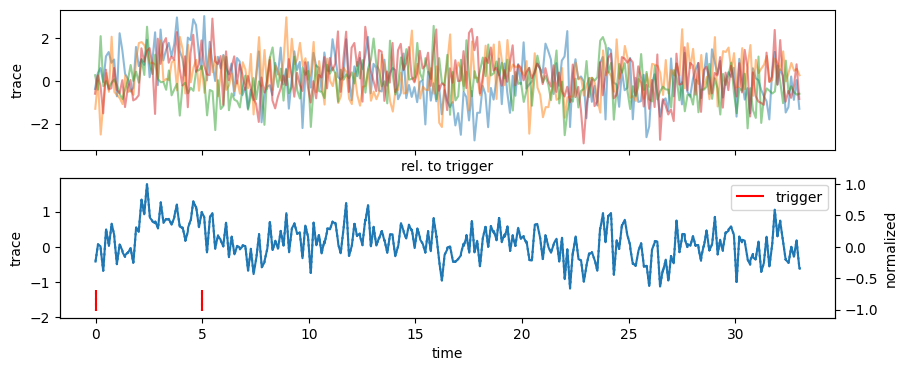

In [38]:
# visualize chirp traces of one key
(openretinawrapper("Averages")()).plot1(key=dict(stim_name = "gChirp",roi_id=87))

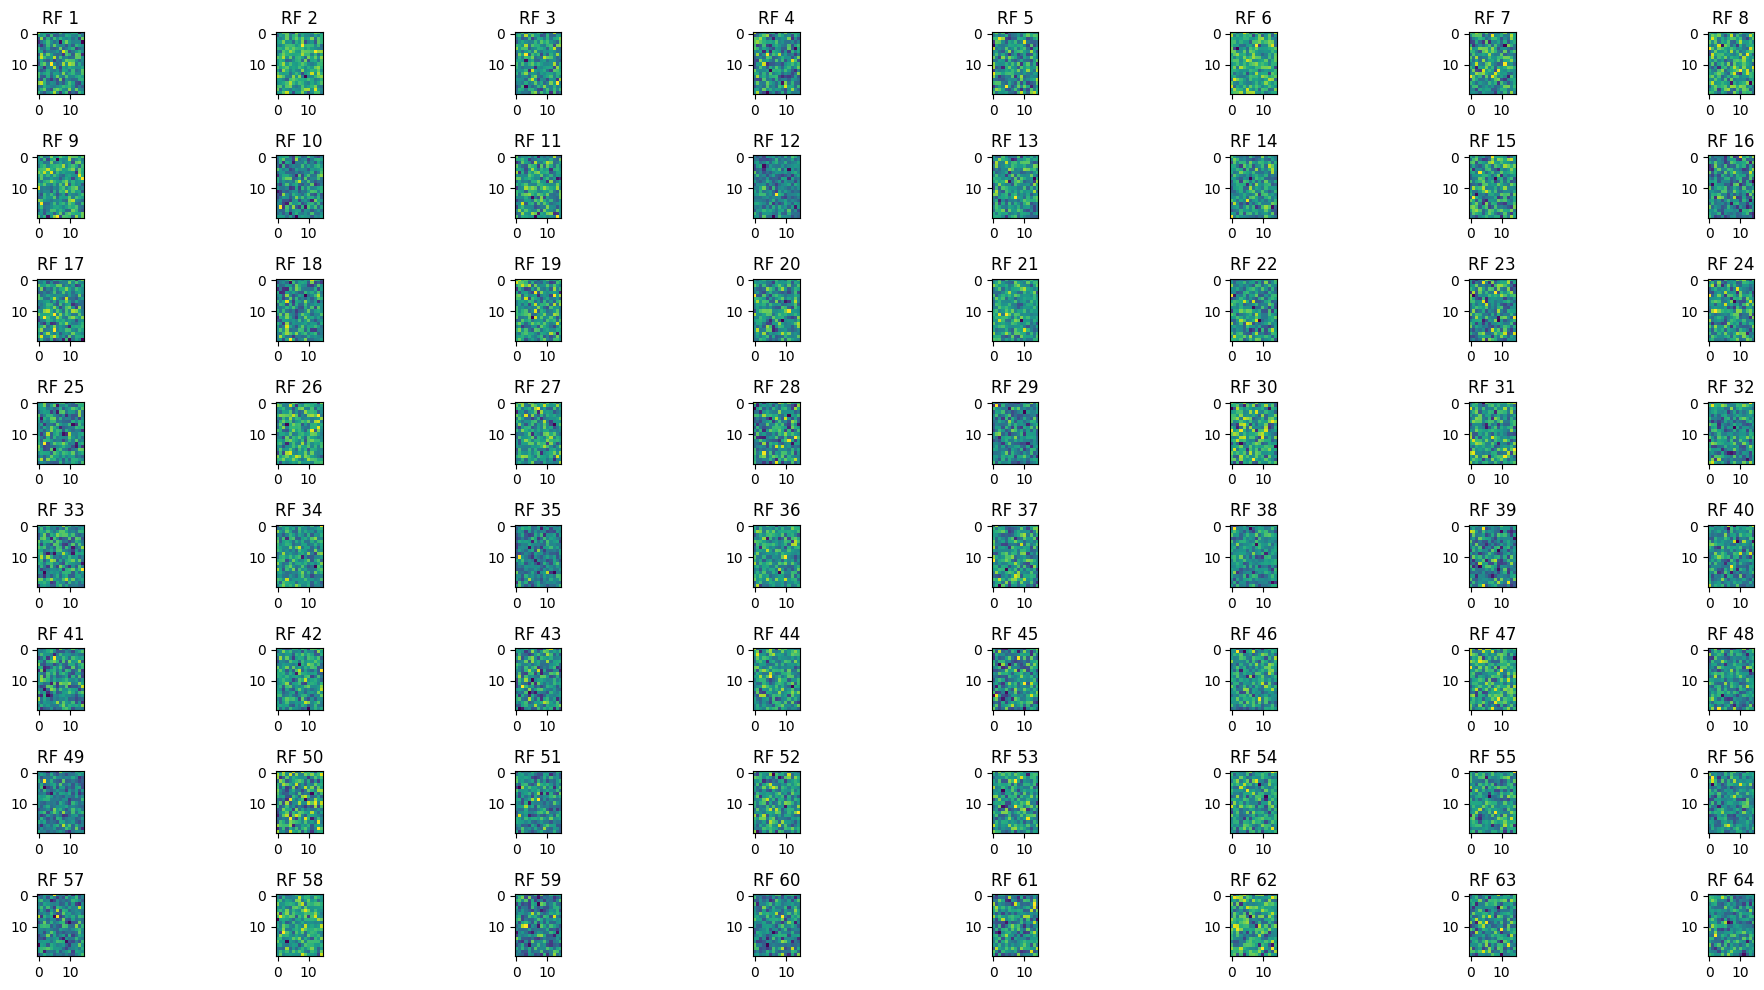

In [92]:
# plot 16 rfs average over time
fig,ax = plt.subplots(8, 8, figsize=(20, 10))
for i in range(64):
    if i < len(avg_over_time):
        ax[i//8, i%8].imshow(avg_over_time[i])
    ax[i//8, i%8].set_title(f"RF {i+1}")
plt.tight_layout()

In [39]:
np.unique(roi_data['roi_mask'])

array([-89, -88, -87, -86, -85, -84, -83, -82, -81, -80, -79, -78, -77,
       -76, -75, -74, -73, -72, -71, -70, -69, -68, -67, -66, -65, -64,
       -63, -62, -61, -60, -59, -58, -57, -56, -55, -54, -53, -52, -51,
       -50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39, -38,
       -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25,
       -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12,
       -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   1])

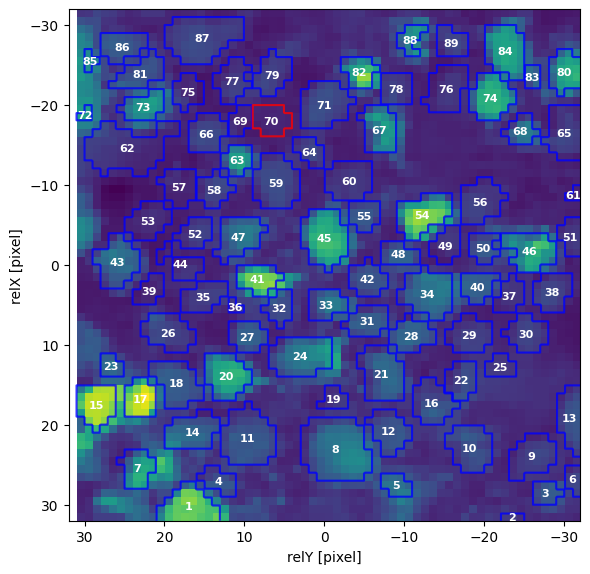

In [60]:
from simulations.gui.utils_gui import plot_stack_and_rois

selected_roi = 70
current_fig, ax = plot_stack_and_rois(
                main_ch_average=field_data['main_ch_average'],
                roi_mask=roi_data['roi_mask'],
                roi_ch_average=field_data['main_ch_average'],
                scan_type=field_data['scan_type'],
                npixartifact=field_data['npixartifact'],
                highlight_roi= [selected_roi],
                figsize=(8, 6),
                gamma=0.5,
            )

In [24]:
from djimaging.utils.plot_utils import plot_field

(<Figure size 800x600 with 5 Axes>,
 array([<Axes: title={'center': 'main average'}, xlabel='relY [pixel]', ylabel='relX [pixel]'>,
        <Axes: title={'center': 'alt average'}, xlabel='relY [pixel]'>,
        <Axes: title={'center': 'roi_mask'}, xlabel='relY [pixel]'>,
        <Axes: title={'center': 'roi2 + data'}, xlabel='relY [pixel]'>],
       dtype=object))

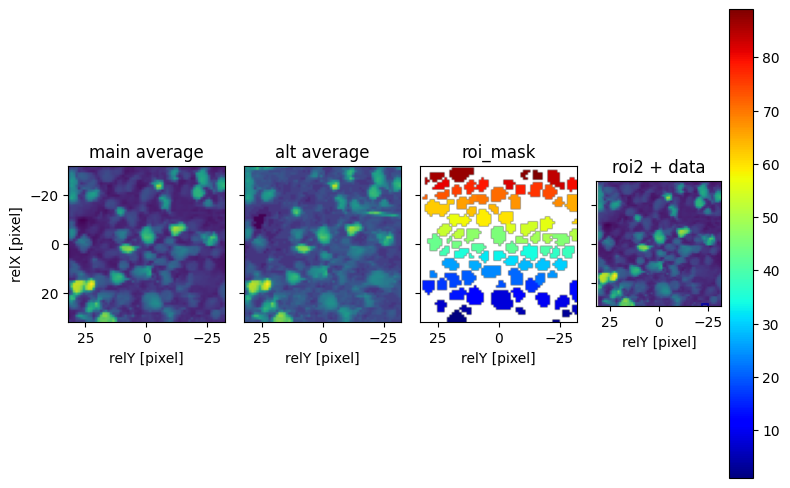

In [ ]:
plot_field(
            main_ch_average=field_data['main_ch_average'],
            roi_mask=roi_data['roi_mask'],
            alt_ch_average=field_data['alt_ch_average'],
            roi_ch_average=field_data['main_ch_average'],
            scan_type=field_data['scan_type'],
            npixartifact=field_data['npixartifact'],
            highlight_roi= selected_roi,
            figsize=(8, 6),
            gamma=0.5,
            )

In [44]:
# Import numpy which was missing from the above code
import numpy as np

# Create the visualization GUI instance
visualization_gui = VisualizationGUI(openretinawrapper)

# Create and display the GUI
gui_widget = visualization_gui.start_gui()
display(gui_widget)



Loaded 89 ROIs
